# 15. Multi-Band Spectrum Prediction via SSA and A-BiLSTM

Implements **SSA + BiLSTM with attention (A-BiLSTM)** from the paper:
**"Multi-band Spectrum Prediction Method via Singular Spectrum Analysis and A-BiLSTM"** (IEEE ICCT 2023).

## Paper (adapted to our setting)
- **SSA:** Decompose the time series (trajectory matrix → SVD → diagonal averaging) into components (trend, periodic, noise).
- **Per-component prediction:** For each component, train an **A-BiLSTM** (BiLSTM + attention over hidden states). Paper: s_t = tanh(h_t·W_h+b), α_t = softmax(s_t), o = Σ α_t h_t; then predict from o.
- **Final prediction:** Sum the predicted components: y_pred = Σ y^j_pred.
- **Training:** SSA on concatenated (72h input + 24h target) → components of length 96; use first 72 as input, last 24 as target per component. **Test:** SSA on 72h only → components length 72; each A-BiLSTM predicts 24; sum.

## Same setup as 10–14
Data: work_dir/final, 72h→24h. Metrics: MAE, RMSE, MASE. Models: SSA+A-BiLSTM, BiLSTM only, Naive. Same visuals.


**GPU:** Use kernel **Python 3.11 (cablelabs-3 .venv)** (Kernel → Change kernel) so TensorFlow uses the project's venv with tensorflow-metal.

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
print(f'TensorFlow: {tf.__version__}')


TensorFlow: 2.18.1


In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_visible_devices(gpus, 'GPU')
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'GPU enabled: {len(gpus)} device(s)')
        with tf.device('/GPU:0'):
            _ = tf.constant(1)
        print('GPU ready.')
    except RuntimeError as e: print('GPU config:', e)
else: print('No GPU found. Change kernel to "Python 3.11 (cablelabs-3 .venv)" (Kernel → Change kernel), then re-run from the top.')
USE_GPU = len(gpus) > 0


GPU enabled: 1 device(s)
GPU ready.


2026-02-09 22:16:16.709924: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-02-09 22:16:16.709949: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-02-09 22:16:16.709954: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1770693376.709964 42145715 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1770693376.709978 42145715 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## Data loading (same as notebook 10)

In [3]:
work_dir = Path("work_dir")
if not work_dir.exists():
    work_dir = Path("../work_dir")
final_dir = work_dir / "final"
training_dir = final_dir / "training"
testing_dir = final_dir / "testing"
if not final_dir.exists() or not training_dir.exists() or not testing_dir.exists():
    raise FileNotFoundError("work_dir/final/training and testing not found")
class_options = sorted([d.name for d in training_dir.iterdir() if d.is_dir()])
LOOKBACK = 72
FORECAST_HORIZON = 24
print(f"Bands: {class_options}, Lookback={LOOKBACK}, Horizon={FORECAST_HORIZON}")

def load_data_for_band(band_name: str, split: str):
    split_dir = final_dir / split / band_name
    if not split_dir.exists():
        return pd.DataFrame()
    dfs = []
    for p in sorted(split_dir.glob("final_*.parquet")):
        try:
            dfs.append(pd.read_parquet(p))
        except Exception as e:
            print(f"Error loading {p}: {e}")
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

def prepare_next_day_sequences(train_df, test_df, lookback=72, forecast_horizon=24):
    freqs = sorted(train_df["freq_center_ghz"].unique())
    ths = sorted(train_df["threshold_dbm"].unique())
    if len(ths) > 1:
        train_df = train_df[train_df["threshold_dbm"] == ths[0]].copy()
        test_df = test_df[test_df["threshold_dbm"] == ths[0]].copy()
    X_tr, y_tr, X_te, y_te = [], [], [], []
    for freq in freqs:
        tr = train_df[train_df["freq_center_ghz"] == freq].sort_values(["date", "hour"])["au_pct"].values
        te = test_df[test_df["freq_center_ghz"] == freq].sort_values(["date", "hour"])["au_pct"].values
        for i in range(len(tr) - lookback - forecast_horizon + 1):
            X_tr.append(tr[i:i+lookback])
            y_tr.append(tr[i+lookback:i+lookback+forecast_horizon])
        n_test_days = len(te) // forecast_horizon
        for d in range(n_test_days):
            if d == 0:
                inp = tr[-lookback:] if len(tr) >= lookback else np.concatenate([np.zeros(lookback - len(tr)), tr])
            else:
                h = max(0, lookback - d * forecast_horizon)
                inp = np.concatenate([tr[-h:], te[0:d*forecast_horizon]]) if h > 0 else te[d*forecast_horizon - lookback:d*forecast_horizon]
            tgt = te[d*forecast_horizon:(d+1)*forecast_horizon]
            if len(inp) == lookback and len(tgt) == forecast_horizon:
                X_te.append(inp)
                y_te.append(tgt)
    if not X_tr or not X_te:
        return np.array([]), np.array([]), np.array([]), np.array([])
    return np.array(X_tr).reshape(-1, lookback, 1), np.array(y_tr), np.array(X_te).reshape(-1, lookback, 1), np.array(y_te)

Bands: ['195MHz', '2441MHz', '3765MHz', '539MHz', '5500MHz', '915MHz'], Lookback=72, Horizon=24


In [4]:
train_data_by_band = {}
test_data_by_band = {}
for band in class_options:
    tr = load_data_for_band(band, "training")
    te = load_data_for_band(band, "testing")
    if not tr.empty and not te.empty:
        train_data_by_band[band] = tr
        test_data_by_band[band] = te
X_train_list, y_train_list, X_test_list, y_test_list = [], [], [], []
for band in class_options:
    if band not in train_data_by_band:
        continue
    X_tr, y_tr, X_te, y_te = prepare_next_day_sequences(train_data_by_band[band], test_data_by_band[band], LOOKBACK, FORECAST_HORIZON)
    if len(X_tr) > 0 and len(X_te) > 0:
        X_train_list.append(X_tr)
        y_train_list.append(y_tr)
        X_test_list.append(X_te)
        y_test_list.append(y_te)
X_train = np.vstack(X_train_list)
y_train = np.vstack(y_train_list)
X_test = np.vstack(X_test_list)
y_test = np.vstack(y_test_list)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (30821, 72, 1), Test: (1887, 72, 1)


## SSA decomposition (paper: trajectory matrix → SVD → diagonal averaging)

In [5]:
L_SSA = 20
N_COMP = 4

def _diag_average(X):
    L, K = X.shape
    n = L + K - 1
    y = np.zeros(n)
    for k in range(n):
        i_lo = max(0, k - K + 1)
        i_hi = min(k, L - 1)
        y[k] = np.mean([X[i, k - i] for i in range(i_lo, i_hi + 1)])
    return y

def ssa_decompose(series: np.ndarray, L: int, n_comp: int):
    x = series.astype(float)
    n = len(x)
    if L < 2 or n < L:
        return [x.copy()]
    K = n - L + 1
    X = np.column_stack([x[i:i+L] for i in range(K)])
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    m = min(n_comp, len(s))
    comps = []
    for i in range(m):
        Xi = (U[:, [i]] * s[i]) @ Vt[[i], :]
        comps.append(_diag_average(Xi))
    return comps

# Training: SSA on (72+24)=96 to get component targets; test: SSA on 72 only
print(f"SSA: L={L_SSA}, n_components={N_COMP}")

SSA: L=20, n_components=4


In [6]:
# Build per-component training data: for each sample, SSA(concat(x_72, y_24)) → components length 96; input 72, target 24
train_comps_X = [[] for _ in range(N_COMP)]
train_comps_y = [[] for _ in range(N_COMP)]
for i in range(len(X_train)):
    full = np.concatenate([X_train[i, :, 0], y_train[i]])
    comps = ssa_decompose(full, L_SSA, N_COMP)
    for j in range(len(comps)):
        if len(comps[j]) >= LOOKBACK + FORECAST_HORIZON:
            train_comps_X[j].append(comps[j][:LOOKBACK])
            train_comps_y[j].append(comps[j][LOOKBACK:LOOKBACK+FORECAST_HORIZON])
for j in range(N_COMP):
    train_comps_X[j] = np.array(train_comps_X[j], dtype=np.float32).reshape(-1, LOOKBACK, 1)
    train_comps_y[j] = np.array(train_comps_y[j], dtype=np.float32)
print("Per-component train shapes:", [train_comps_X[j].shape for j in range(N_COMP)])

Per-component train shapes: [(30821, 72, 1), (30821, 72, 1), (30821, 72, 1), (30821, 72, 1)]


## A-BiLSTM (BiLSTM + attention over time, paper Eq. 11)

In [7]:
def build_abilstm(lookback, horizon, units=32):
    inp = layers.Input(shape=(lookback, 1))
    bilstm = layers.Bidirectional(layers.LSTM(units, return_sequences=True, activation="tanh"))(inp)
    # Attention: s_t = tanh(W_h @ h_t + b), alpha = softmax(s), o = sum(alpha_t * h_t)
    attn_dense = layers.Dense(1, activation="tanh")(bilstm)
    attn_weights = layers.Softmax(axis=1)(attn_dense)
    context = layers.Multiply()([bilstm, attn_weights])
    context = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(context)
    out = layers.Dense(horizon, activation="linear")(context)
    return keras.Model(inp, out)

In [8]:
# Scale per-component (input and target) for stable training
scaler_X_j = [MinMaxScaler(feature_range=(0, 1)) for _ in range(N_COMP)]
scaler_y_j = [MinMaxScaler(feature_range=(0, 1)) for _ in range(N_COMP)]
train_X_s = []
train_y_s = []
for j in range(N_COMP):
    B = train_comps_X[j].shape[0]
    x_flat = train_comps_X[j].reshape(-1, 1)
    y_flat = train_comps_y[j].reshape(-1, 1)
    train_X_s.append(scaler_X_j[j].fit_transform(x_flat).reshape(-1, LOOKBACK, 1))
    train_y_s.append(scaler_y_j[j].fit_transform(y_flat).reshape(-1, FORECAST_HORIZON))

EPOCHS = 50
BATCH = 128 if USE_GPU else 32
models_j = []
for j in range(N_COMP):
    m = build_abilstm(LOOKBACK, FORECAST_HORIZON, units=32)
    m.compile(optimizer=keras.optimizers.Adam(0.001), loss="mse", metrics=["mae"])
    m.fit(train_X_s[j], train_y_s[j], epochs=EPOCHS, batch_size=BATCH, validation_split=0.2, verbose=1)
    models_j.append(m)
print("Per-component A-BiLSTM trained.")

Epoch 1/50


2026-02-09 22:17:04.931130: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


193/193 ━━━━━━━━━━━━━━━━━━━━ 23s 101ms/step - loss: 0.0154 - mae: 0.0592 - val_loss: 0.0029 - val_mae: 0.0379
Epoch 2/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 18s 96ms/step - loss: 0.0026 - mae: 0.0268 - val_loss: 0.0020 - val_mae: 0.0264
Epoch 3/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 18s 95ms/step - loss: 0.0022 - mae: 0.0249 - val_loss: 0.0021 - val_mae: 0.0257
Epoch 4/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - loss: 0.0021 - mae: 0.0248 - val_loss: 0.0017 - val_mae: 0.0241
Epoch 5/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - loss: 0.0020 - mae: 0.0239 - val_loss: 0.0020 - val_mae: 0.0249
Epoch 6/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - loss: 0.0018 - mae: 0.0223 - val_loss: 0.0016 - val_mae: 0.0291
Epoch 7/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 19s 101ms/step - loss: 0.0016 - mae: 0.0211 - val_loss: 0.0015 - val_mae: 0.0286
Epoch 8/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 18s 95ms/step - loss: 0.0015 - mae: 0.0206 - val_loss: 0.0013 - val_mae: 0.0226
Epoch 9/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 18s 95ms/

In [9]:
# Test: SSA on 72h only → components length 72; predict each component, inverse scale, sum
y_pred_ssa_abilstm = np.zeros((len(X_test), FORECAST_HORIZON))
for i in range(len(X_test)):
    x72 = X_test[i, :, 0]
    comps = ssa_decompose(x72, L_SSA, N_COMP)
    pred_sum = np.zeros(FORECAST_HORIZON)
    for j in range(min(len(comps), N_COMP)):
        c = comps[j].astype(np.float32).reshape(1, LOOKBACK, 1)
        c_s = scaler_X_j[j].transform(c.reshape(-1, 1)).reshape(1, LOOKBACK, 1)
        p_s = models_j[j].predict(c_s, verbose=0)[0]
        p = scaler_y_j[j].inverse_transform(p_s.reshape(-1, 1)).ravel()
        pred_sum += p
    y_pred_ssa_abilstm[i] = pred_sum
print("SSA+A-BiLSTM predictions done.")

SSA+A-BiLSTM predictions done.


In [10]:
# BiLSTM only (no SSA, no attention) and Naive
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
X_train_flat = X_train.reshape(-1, 1)
X_test_flat = X_test.reshape(-1, 1)
y_train_flat = y_train.reshape(-1, 1)
X_train_scaled = scaler_X.fit_transform(X_train_flat).reshape(X_train.shape)
X_test_scaled = scaler_X.transform(X_test_flat).reshape(X_test.shape)
y_train_scaled = scaler_y.fit_transform(y_train_flat).reshape(y_train.shape)

model_bilstm = keras.Sequential([
    layers.Bidirectional(layers.LSTM(32, activation="tanh"), input_shape=(LOOKBACK, 1)),
    layers.Dense(FORECAST_HORIZON, activation="linear"),
])
model_bilstm.compile(optimizer=keras.optimizers.Adam(0.001), loss="mse", metrics=["mae"])
model_bilstm.fit(X_train_scaled, y_train_scaled, epochs=EPOCHS, batch_size=BATCH, validation_split=0.2, verbose=1)
y_pred_bilstm_scaled = model_bilstm.predict(X_test_scaled, verbose=0)
y_pred_bilstm = scaler_y.inverse_transform(y_pred_bilstm_scaled.reshape(-1, 1)).reshape(y_test.shape)

def naive_predictor(X, horizon):
    last = X[:, -1, 0]
    return np.tile(last.reshape(-1, 1), (1, horizon))
y_pred_naive = naive_predictor(X_test, FORECAST_HORIZON)

def calculate_mae(y_true, y_pred):
    return mean_absolute_error(y_true.flatten(), y_pred.flatten())
def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
def calculate_mase(y_true, y_pred, y_train):
    mae = np.mean(np.abs(y_true.flatten() - y_pred.flatten()))
    scale = np.mean(np.abs(np.diff(y_train.flatten()))) if len(y_train.flatten()) > 1 else 1.0
    return mae / max(scale, 1e-8)

Epoch 1/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 15s 72ms/step - loss: 0.0240 - mae: 0.0770 - val_loss: 0.0080 - val_mae: 0.0573
Epoch 2/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - loss: 0.0081 - mae: 0.0468 - val_loss: 0.0083 - val_mae: 0.0576
Epoch 3/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - loss: 0.0078 - mae: 0.0450 - val_loss: 0.0079 - val_mae: 0.0533
Epoch 4/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - loss: 0.0077 - mae: 0.0444 - val_loss: 0.0074 - val_mae: 0.0501
Epoch 5/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 12s 64ms/step - loss: 0.0075 - mae: 0.0438 - val_loss: 0.0070 - val_mae: 0.0492
Epoch 6/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - loss: 0.0073 - mae: 0.0431 - val_loss: 0.0073 - val_mae: 0.0489
Epoch 7/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - loss: 0.0069 - mae: 0.0418 - val_loss: 0.0073 - val_mae: 0.0492
Epoch 8/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - loss: 0.0062 - mae: 0.0396 - val_loss: 0.0062 - val_mae: 0.0499
Epoch 9/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 

In [11]:
# Results table (same format as notebook 10)
mae_s = calculate_mae(y_test, y_pred_ssa_abilstm)
rmse_s = calculate_rmse(y_test, y_pred_ssa_abilstm)
mase_s = calculate_mase(y_test, y_pred_ssa_abilstm, y_train)
mae_bi = calculate_mae(y_test, y_pred_bilstm)
rmse_bi = calculate_rmse(y_test, y_pred_bilstm)
mase_bi = calculate_mase(y_test, y_pred_bilstm, y_train)
mae_n = calculate_mae(y_test, y_pred_naive)
rmse_n = calculate_rmse(y_test, y_pred_naive)
mase_n = calculate_mase(y_test, y_pred_naive, y_train)

results_df = pd.DataFrame([
    {"Model": "SSA+A-BiLSTM", "MAE": mae_s, "RMSE": rmse_s, "MASE": mase_s},
    {"Model": "BiLSTM only", "MAE": mae_bi, "RMSE": rmse_bi, "MASE": mase_bi},
    {"Model": "Naive Baseline", "MAE": mae_n, "RMSE": rmse_n, "MASE": mase_n},
])
results_df["MAE"] = results_df["MAE"].round(4)
results_df["RMSE"] = results_df["RMSE"].round(4)
results_df["MASE"] = results_df["MASE"].round(4)

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY (same format as notebook 10)")
print("="*80)
print(f"Lookback: {LOOKBACK}h, Forecast: {FORECAST_HORIZON}h")
print(f"Test samples: {len(y_test)}")
print(f"\n{results_df.to_string(index=False)}")
display(results_df)


FINAL RESULTS SUMMARY (same format as notebook 10)
Lookback: 72h, Forecast: 24h
Test samples: 1887

         Model    MAE    RMSE   MASE
  SSA+A-BiLSTM 5.0178  9.1277 2.4068
   BiLSTM only 4.5433  9.2827 2.1792
Naive Baseline 4.4497 10.2349 2.1343


,Model,MAE,RMSE,MASE
0,SSA+A-BiLSTM,5.0178,9.1277,2.4068
1,BiLSTM only,4.5433,9.2827,2.1792
2,Naive Baseline,4.4497,10.2349,2.1343


## Analysis and Visualizations (same as notebook 10)

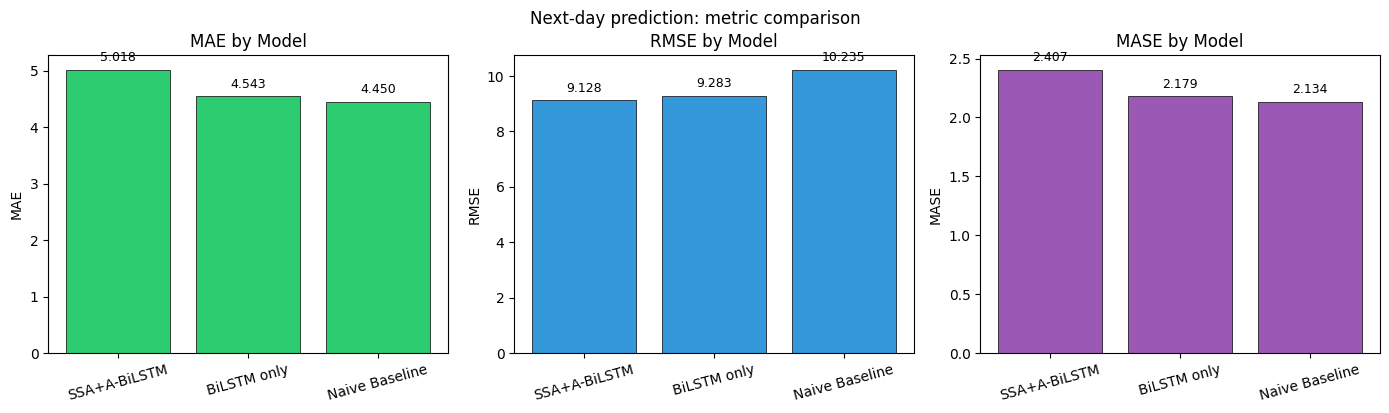

In [12]:
# 1. Bar charts: MAE, RMSE, MASE
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['MAE', 'RMSE', 'MASE']
colors = ['#2ecc71', '#3498db', '#9b59b6']
for ax, metric, color in zip(axes, metrics, colors):
    vals = results_df[metric].values
    bars = ax.bar(results_df['Model'], vals, color=color, edgecolor='black', linewidth=0.5)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Model')
    ax.tick_params(axis='x', rotation=15)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02 * max(vals), f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.suptitle('Next-day prediction: metric comparison', y=1.02, fontsize=12)
plt.show()

Improvement over Naive Baseline (%):


,Model,MAE_imp_%,RMSE_imp_%,MASE_imp_%
0,SSA+A-BiLSTM,-12.77,10.82,-12.77
1,BiLSTM only,-2.10,9.30,-2.10


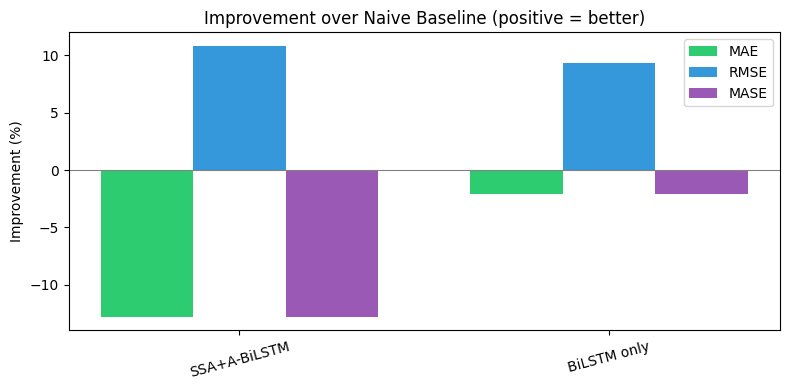

In [13]:
# 2. Improvement over Naive Baseline (%)
naive_mae = results_df[results_df['Model'] == 'Naive Baseline']['MAE'].values[0]
naive_rmse = results_df[results_df['Model'] == 'Naive Baseline']['RMSE'].values[0]
naive_mase = results_df[results_df['Model'] == 'Naive Baseline']['MASE'].values[0]
improvement = results_df[results_df['Model'] != 'Naive Baseline'].copy()
improvement['MAE_imp_%'] = (1 - improvement['MAE'] / naive_mae) * 100
improvement['RMSE_imp_%'] = (1 - improvement['RMSE'] / naive_rmse) * 100
improvement['MASE_imp_%'] = (1 - improvement['MASE'] / naive_mase) * 100
print('Improvement over Naive Baseline (%):')
display(improvement[['Model', 'MAE_imp_%', 'RMSE_imp_%', 'MASE_imp_%']].round(2))
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(improvement))
w = 0.25
ax.bar(x - w, improvement['MAE_imp_%'], w, label='MAE', color='#2ecc71')
ax.bar(x, improvement['RMSE_imp_%'], w, label='RMSE', color='#3498db')
ax.bar(x + w, improvement['MASE_imp_%'], w, label='MASE', color='#9b59b6')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(improvement['Model'], rotation=15)
ax.set_ylabel('Improvement (%)')
ax.legend()
ax.set_title('Improvement over Naive Baseline (positive = better)')
plt.tight_layout()
plt.show()

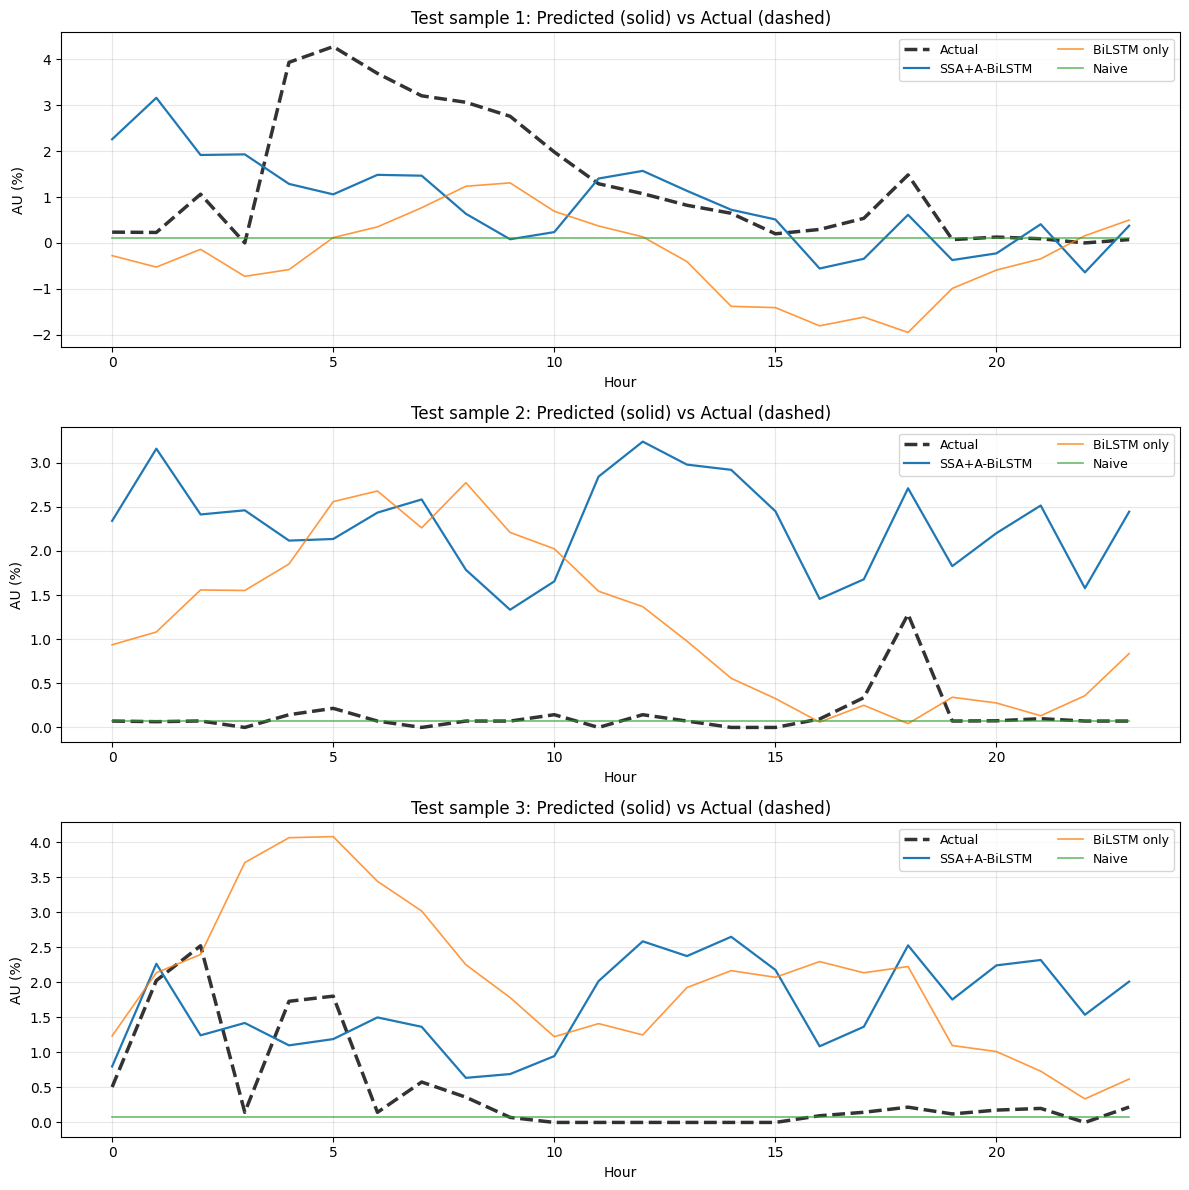

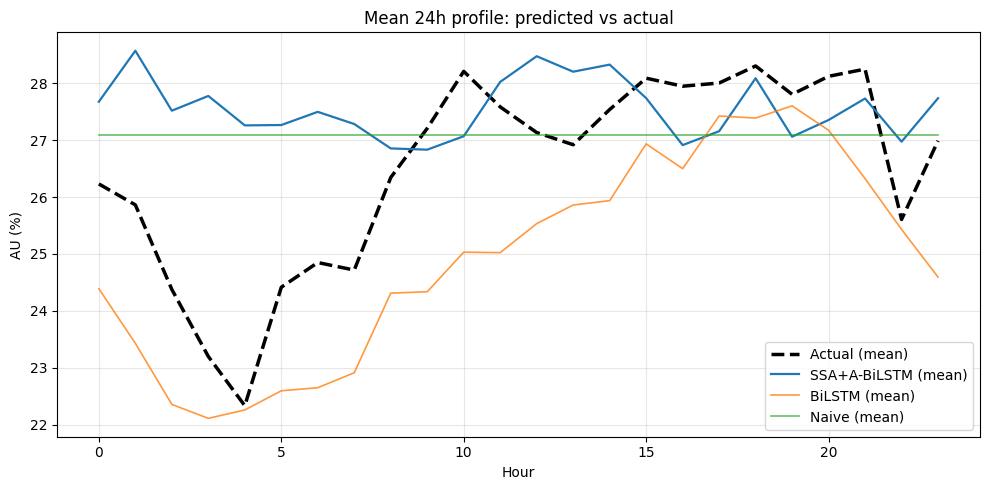

In [14]:
# 3. Predicted vs Actual (up to 3 samples, actual dashed) + mean profile
hours = np.arange(FORECAST_HORIZON)
n_show = min(3, len(y_test))
fig, axes = plt.subplots(n_show, 1, figsize=(12, 4*n_show))
if n_show == 1:
    axes = [axes]
for i in range(n_show):
    ax = axes[i]
    ax.plot(hours, y_test[i], 'k--', linewidth=2.5, label='Actual', alpha=0.8)
    ax.plot(hours, y_pred_ssa_abilstm[i], '-', linewidth=1.6, label='SSA+A-BiLSTM')
    ax.plot(hours, y_pred_bilstm[i], '-', linewidth=1.2, label='BiLSTM only', alpha=0.8)
    ax.plot(hours, y_pred_naive[i], '-', linewidth=1.2, label='Naive', alpha=0.7)
    ax.set_title(f'Test sample {i+1}: Predicted (solid) vs Actual (dashed)')
    ax.set_xlabel('Hour')
    ax.set_ylabel('AU (%)')
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hours, y_test.mean(axis=0), 'k--', linewidth=2.5, label='Actual (mean)')
ax.plot(hours, y_pred_ssa_abilstm.mean(axis=0), '-', linewidth=1.6, label='SSA+A-BiLSTM (mean)')
ax.plot(hours, y_pred_bilstm.mean(axis=0), '-', linewidth=1.2, label='BiLSTM (mean)', alpha=0.8)
ax.plot(hours, y_pred_naive.mean(axis=0), '-', linewidth=1.2, label='Naive (mean)', alpha=0.7)
ax.set_title('Mean 24h profile: predicted vs actual')
ax.set_xlabel('Hour')
ax.set_ylabel('AU (%)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

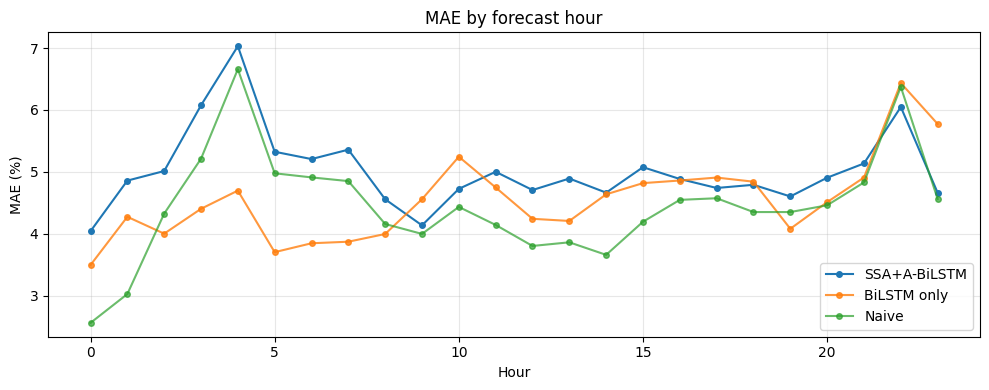

In [15]:
# 4. Per-hour MAE
mae_per_hour_s = np.abs(y_test - y_pred_ssa_abilstm).mean(axis=0)
mae_per_hour_bi = np.abs(y_test - y_pred_bilstm).mean(axis=0)
mae_per_hour_naive = np.abs(y_test - y_pred_naive).mean(axis=0)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hours, mae_per_hour_s, '-o', label='SSA+A-BiLSTM', markersize=4)
ax.plot(hours, mae_per_hour_bi, '-o', label='BiLSTM only', markersize=4, alpha=0.8)
ax.plot(hours, mae_per_hour_naive, '-o', label='Naive', markersize=4, alpha=0.7)
ax.set_title('MAE by forecast hour')
ax.set_xlabel('Hour')
ax.set_ylabel('MAE (%)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

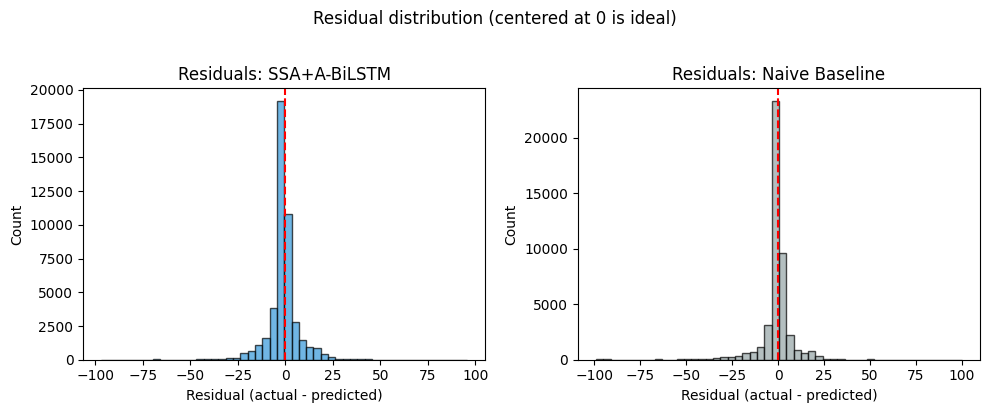

Residual mean (bias): SSA+A-BiLSTM = -1.0562, Naive = -0.5887
Residual std:         SSA+A-BiLSTM = 9.0664, Naive = 10.2179


In [16]:
# 5. Residuals: SSA+A-BiLSTM vs Naive
residuals_best = (y_test - y_pred_ssa_abilstm).flatten()
residuals_naive = (y_test - y_pred_naive).flatten()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(residuals_best, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_xlabel('Residual (actual - predicted)')
axes[0].set_ylabel('Count')
axes[0].set_title('Residuals: SSA+A-BiLSTM')
axes[1].hist(residuals_naive, bins=50, color='#95a5a6', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (actual - predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residuals: Naive Baseline')
plt.suptitle('Residual distribution (centered at 0 is ideal)', y=1.02)
plt.tight_layout()
plt.show()
print(f'Residual mean (bias): SSA+A-BiLSTM = {residuals_best.mean():.4f}, Naive = {residuals_naive.mean():.4f}')
print(f'Residual std:         SSA+A-BiLSTM = {residuals_best.std():.4f}, Naive = {residuals_naive.std():.4f}')

### Key insights

- **SSA+A-BiLSTM (paper):** SSA reduces complexity by decomposing into components; A-BiLSTM (attention over BiLSTM hidden states) focuses on important time steps. Summing per-component predictions gives the final forecast.
- **Improvement over naive:** Positive % means the model beats the last-value baseline.
- **Mean profile / per-hour MAE / residuals:** Same interpretation as notebooks 10–14.

In [17]:
# One-line summary (same format as notebook 10)
best_row = results_df[results_df['Model'] == 'SSA+A-BiLSTM'].iloc[0]
imp_mae = (1 - best_row['MAE'] / naive_mae) * 100
print(f"Best model: SSA+A-BiLSTM (MAE={best_row['MAE']:.4f}, RMSE={best_row['RMSE']:.4f}, MASE={best_row['MASE']:.4f}).")
print(f"Improvement over Naive: MAE {imp_mae:+.1f}%.")

Best model: SSA+A-BiLSTM (MAE=5.0178, RMSE=9.1277, MASE=2.4068).
Improvement over Naive: MAE -12.8%.
